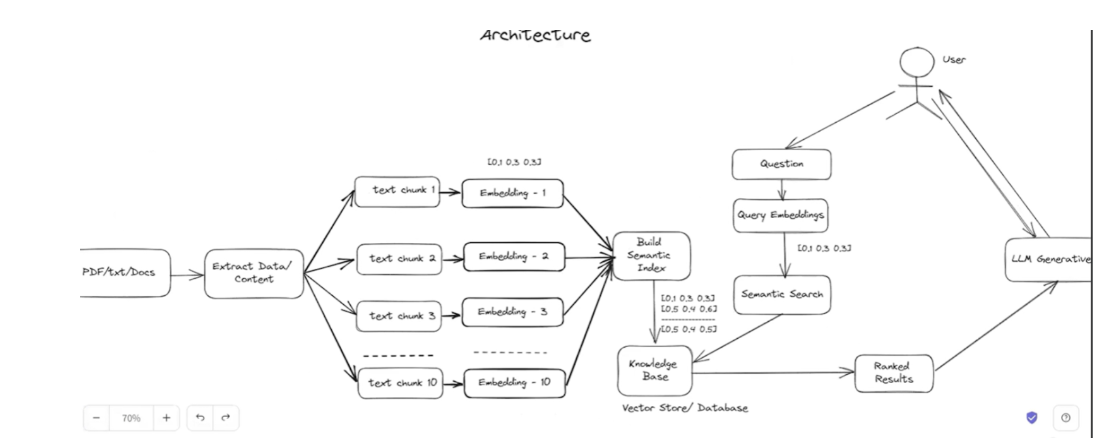

In [23]:
!pip install langchain_community openai tiktoken rapidocr-onnxruntime

In [2]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

In [5]:
import os
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

#Data Ingestion

In [4]:
import requests
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS

In [6]:
with open("state_of_the_union.txt","r", encoding="utf8") as f:
  data = f.read()

In [7]:
loder=TextLoader('state_of_the_union.txt', encoding="utf8")

In [8]:
document=loder.load()

In [9]:
print(document[0].page_content)

Madam Speaker, Madam Vice President, our First Lady and Second Gentleman. Members of Congress and the Cabinet. Justices of the Supreme Court. My fellow Americans.  

Last year COVID-19 kept us apart. This year we are finally together again. 

Tonight, we meet as Democrats Republicans and Independents. But most importantly as Americans. 

With a duty to one another to the American people to the Constitution. 

And with an unwavering resolve that freedom will always triumph over tyranny. 

Six days ago, Russia’s Vladimir Putin sought to shake the foundations of the free world thinking he could make it bend to his menacing ways. But he badly miscalculated. 

He thought he could roll into Ukraine and the world would roll over. Instead he met a wall of strength he never imagined. 

He met the Ukrainian people. 

From President Zelenskyy to every Ukrainian, their fearlessness, their courage, their determination, inspires the world. 

Groups of citizens blocking tanks with their bodies. Every

# Chunking of Data -> Embedding -> Vectorstore Indexing -> Database

In [14]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_spliiter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

In [15]:
text_chunks = text_spliiter.split_documents(document)

In [16]:
print(text_chunks[0].page_content)

Madam Speaker, Madam Vice President, our First Lady and Second Gentleman. Members of Congress and the Cabinet. Justices of the Supreme Court. My fellow Americans.  

Last year COVID-19 kept us apart. This year we are finally together again. 

Tonight, we meet as Democrats Republicans and Independents. But most importantly as Americans. 

With a duty to one another to the American people to the Constitution. 

And with an unwavering resolve that freedom will always triumph over tyranny.


In [17]:
from langchain_community.embeddings import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

In [18]:
embeddings = OpenAIEmbeddings()

<ipython-input-18-73ad2f8e367a>:1: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings()


In [24]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 58.9 MB/s eta 0:00:00


In [25]:
vectorstore = FAISS.from_documents(text_chunks, embeddings)

In [26]:
retriever = vectorstore.as_retriever()

In [27]:
from langchain.prompts import ChatPromptTemplate

In [30]:
template="""You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use ten sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:
"""
prompt=ChatPromptTemplate.from_template(template)

In [34]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.1 MB/s eta 0:00:00


In [35]:
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser

In [37]:
llm_model = ChatOpenAI(model_name="gpt-4o-mini")

In [39]:
output_parser = StrOutputParser()
rag_chain = {"context": retriever, "question": RunnablePassthrough()} | prompt | llm_model | output_parser
# RunnablePassthrough lets you provide the query during runtime

In [40]:
rag_chain.invoke("How is the US supporting Ukraine during war?")

"The United States is supporting Ukraine through a multifaceted approach. This includes military, economic, and humanitarian assistance, with over $1 billion in direct aid already provided. The U.S. supports the Ukrainian people's fight for freedom while making it clear that American forces will not engage directly in combat with Russian forces. Instead, U.S. military resources are focused on defending NATO allies in Eastern Europe, including Poland and the Baltic states. The U.S. seeks to send a strong signal of support to Ukraine and deter further aggression from Russia. This involvement also reinforces the purpose of NATO, which was established to maintain peace and stability in Europe. The support aims to ease the suffering of the Ukrainian people as they defend their homeland. Overall, the U.S. stands in solidarity with Ukraine amidst ongoing conflict."